# Expression analysis SHMss events

In [3]:
# Load packages
options(warn = -1)
library("IRdisplay")
library(tidyverse)
library(Seurat)
library(ggh4x)

── Attaching packages ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 1.3.2 ──
✔ ggplot2 3.4.0      ✔ purrr   1.0.1 
✔ tibble  3.1.8      ✔ dplyr   1.0.10
✔ tidyr   1.3.0      ✔ stringr 1.5.0 
✔ readr   2.1.3      ✔ forcats 0.5.2 
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
Attaching SeuratObject



In [2]:
suppressMessages(source("code/functions.R"))

## Load data

### Load input data (all sequences)

In [3]:
df_seq <- Sys.glob("input/output_shm_v4up/FL/consensus/*/*.csv") %>%
  purrr::map_dfr(function(x) {
    readr::read_csv(x, col_types = "cciccici", progress = FALSE) %>%
      dplyr::mutate(subject = gsub("^.*/|.csv*$", "", x)) %>%
      filter(ref_vdj_coverage == "1.0")
  })

### Load list of cells with complete VDJ

In [4]:
df_complete_cells <- read.csv("input/complete_cells.csv")

### Load all SHMss events detected (positive + false positive)

In [5]:
# load data
df <- Sys.glob("input/shm_incl_po_subrg.20210912/FL/*/*.csv") %>%
  purrr::map_dfr(function(x) {
    readr::read_csv(x, col_types = "ccicccilciicc", progress = FALSE) %>%
      dplyr::mutate(subject = gsub("^.*/|\\.shm.*$", "", x))
  })

In [6]:
head(df)

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
AAACGGGCATCACGTA,GCAGGCAGTG,290,G,T,NN.TT,9,TRUE,L,NA,NA,-,NA,-,K1B_S10000-HC
AAACGGGCATCACGTA,TAGCCGTATA,290,G,G,CA.CC,91,TRUE,L,NA,NA,-,NA,-,K1B_S10000-HC
AAACGGGCATCACGTA,TCACTTGGCC,290,G,G,CA.CC,98,TRUE,L,NA,NA,-,NA,-,K1B_S10000-HC
AACCGCGGTAAATGTG,CGAAGAGGGC,290,G,G,CA.CC,83,TRUE,L,NA,NA,-,NA,-,K1B_S10000-HC
AACCGCGGTAAATGTG,GTTGTAAGCC,290,G,T,NN.TT,9,TRUE,L,NA,NA,-,NA,-,K1B_S10000-HC
ACCAGTACATTTCAGG,GGTTACGCAT,290,G,G,CA.CC,76,TRUE,L,NA,NA,-,NA,-,K1B_S10000-HC


### Load df with filtered SHMss events (trully positive)

In [7]:
df_summary <- read.csv("output/df_summary_K123_v1.csv")
head(df_summary)

,subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
1,K1B_S10000-LC,TTAGGCAGTCGAACAG,10,C,TG.TG,FR1,C-T,10-9,TRUE
2,K1B_S10000-LC,CTAGCCTCAATCACAC,60,C,AT.TC,FR1,C-G,11-14,TRUE
3,K1B_S10000-LC,ACTTTCACATTGTGCA,65,G,CT.CA,FR1,A-G,5-8,TRUE
4,K1B_S10000-LC,CTAGCCTCAATCACAC,150,C,AT.TA,FR2,A-C,7-11,TRUE
5,K1B_S144-HC,CTCGAGGCAATGACCT,33,G,GT.GT,FR1,A-G,5-6,TRUE
6,K1B_S144-HC,GTCACAACAACGATCT,132,G,GG.CT,FR2,C-G,6-6,TRUE


### Load expression data normalized

We saved 2 object class one with SCT transformation and one without

In [4]:
# #read expression data (every experiment)
# K1B <- Read10X(data.dir = paste0("~/repositories/FL_10X_2/111_CellRanger_analysis.freeze01/K1B/GEX/outs/raw_feature_bc_matrix/")) %>%
#   CreateSeuratObject(project = "K1B", min.cells = 3, min.features = 200) #%>% 
# #                 SCTransform( return.only.var.genes = FALSE )


# K2B <- Read10X(data.dir = paste0("~/repositories/FL_10X_2/111_CellRanger_analysis.freeze01/K2B/GEX/outs/raw_feature_bc_matrix/")) %>%
#   CreateSeuratObject(project = "K2B", min.cells = 3, min.features = 200) #%>% 
# #                 SCTransform( return.only.var.genes = FALSE )

# K3B <- Read10X(data.dir = paste0("~/repositories/FL_10X_2/111_CellRanger_analysis.freeze01/K3B/GEX/outs/raw_feature_bc_matrix/")) %>%
#   CreateSeuratObject(project = "K3B", min.cells = 3, min.features = 200) #%>% 
# #                 SCTransform( return.only.var.genes = FALSE )

In [5]:
# # save every object
# saveRDS(K1B, "output/K1B.rds")
# saveRDS(K2B, "output/K2B.rds")
# saveRDS(K3B, "output/K3B.rds")

# # save every object (with sct transformation)
# saveRDS(K1B, "output/K1B_SCT.rds")
# saveRDS(K2B, "output/K2B_SCT.rds")
# saveRDS(K3B, "output/K3B_SCT.rds")

In [10]:
# # compbined the 3 experiments
# FL_combined <- merge(K1B, y = c(K2B, K3B), add.cell.ids = c("K1B", "K2B", "K3B"), project = "FL")
# FL_combined

In [11]:
# # save integrated object
# saveRDS(FL_combined, "output/K123_SCT_merge.rds")

In [12]:
# Read integrated object
FL_combined <- readRDS("output/K123_SCT_merge.rds")

# List of genes

In [13]:
filename <- "input/names_genes_dna_repair.csv"
genes_names <- read.csv(filename)

In [14]:
# number of genes analysed
length(genes_names$gene)

[1] 66

## **Analysis non normal data**

In [15]:
# filter only the GEX for the list of genes
dd <- FL_combined@assays$RNA@counts %>% #FL_combined@assays$RNA@counts
  as.data.frame() %>%
  rownames_to_column(var = "gene") %>%
  filter(gene %in% genes_names$gene) %>%
  column_to_rownames(var = "gene") %>%
  t() %>%
  as.data.frame() %>%
  rownames_to_column(var = "cell")

head(dd)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,MSH6,APLF,⋯,RPA1,LIG3,PCNA,CHAF1A,XRCC1,LIG1,PNKP,POLD1,CHAF1B,MSH4
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,K1B_AAACCTGAGATCACGG-1,0,0,0,0,3,0,0,0,1,⋯,0,0,0,0,0,0,0,0,0,0
2,K1B_AAACCTGAGCCAGTTT-1,0,0,1,1,3,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,K1B_AAACCTGAGCGGCTTC-1,0,0,1,0,0,0,0,0,1,⋯,0,0,0,0,0,0,0,0,0,0
4,K1B_AAACCTGAGGCATGTG-1,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,1,0,0,0,0
5,K1B_AAACCTGAGTGTTTGC-1,1,0,0,0,2,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,K1B_AAACCTGCAACTGCTA-1,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [16]:
# clean df and include experiment column
pd <- dd %>%
  mutate(experiment = str_sub(cell, 1, 3)) %>% # str_extract("/\/$/", cell
  mutate(cell = gsub("^.{4}|.{2}$", "", cell)) # %>%
#       mutate(UNG_cat=ifelse(UNG == 0, "No", "Yes"))
head(pd)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,MSH6,APLF,⋯,LIG3,PCNA,CHAF1A,XRCC1,LIG1,PNKP,POLD1,CHAF1B,MSH4,experiment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,AAACCTGAGATCACGG,0,0,0,0,3,0,0,0,1,⋯,0,0,0,0,0,0,0,0,0,K1B
2,AAACCTGAGCCAGTTT,0,0,1,1,3,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,K1B
3,AAACCTGAGCGGCTTC,0,0,1,0,0,0,0,0,1,⋯,0,0,0,0,0,0,0,0,0,K1B
4,AAACCTGAGGCATGTG,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,1,0,0,0,0,K1B
5,AAACCTGAGTGTTTGC,1,0,0,0,2,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,K1B
6,AAACCTGCAACTGCTA,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,K1B


**Categorical**

In [17]:
# tranform values to categorical
pd_cat <- pd %>%
  mutate_if(is.numeric, ~ ifelse(. == 0, "No", "Yes"))
head(pd_cat)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,MSH6,APLF,⋯,LIG3,PCNA,CHAF1A,XRCC1,LIG1,PNKP,POLD1,CHAF1B,MSH4,experiment
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGAGATCACGG,No,No,No,No,Yes,No,No,No,Yes,⋯,No,No,No,No,No,No,No,No,No,K1B
2,AAACCTGAGCCAGTTT,No,No,Yes,Yes,Yes,No,No,No,No,⋯,No,No,No,No,No,No,No,No,No,K1B
3,AAACCTGAGCGGCTTC,No,No,Yes,No,No,No,No,No,Yes,⋯,No,No,No,No,No,No,No,No,No,K1B
4,AAACCTGAGGCATGTG,No,No,No,No,Yes,No,No,No,No,⋯,No,No,No,No,Yes,No,No,No,No,K1B
5,AAACCTGAGTGTTTGC,Yes,No,No,No,Yes,No,No,No,No,⋯,No,No,No,No,No,No,No,No,No,K1B
6,AAACCTGCAACTGCTA,No,No,No,No,Yes,No,No,No,No,⋯,No,No,No,No,No,No,No,No,No,K1B


In [18]:
# merge SHMss and expression data
cell_list <- df_summary %>%
  mutate(
    experiment = str_sub(subject, 1, 3),
    group = "SHMss_observed"
  ) %>%
  select(experiment, cell, group) %>%
  distinct() %>%
  right_join(pd_cat, by = c("cell", "experiment")) %>%
  mutate(group = ifelse(is.na(group), "SHMss_not_observed", "SHMss_observed"))

In [19]:
# remove incomplete cells and possible false positives
false_positives <- df %>%
  mutate(experiment = str_sub(subject, 1, 3), group = "SHMss_not_observed") %>%
  select(experiment, cell, group) %>%
  distinct()

cell_list <- cell_list %>%
  right_join(df_complete_cells) %>%
  anti_join(false_positives)

Joining, by = c("experiment", "cell")
Joining, by = c("experiment", "cell", "group")


In [20]:
# summarize data
shm_perc_sub <-  cell_list %>%
  gather(-subject, -experiment, -cell, -group, key = "gene", value = "expression") %>%
  select(-experiment, -cell) %>%
  group_by(subject, gene, group, expression) %>%
  summarise(count = n(), .groups="drop_last") %>%
  mutate(perc = count / sum(count) * 100) %>%
  left_join(genes_names, by = c("gene")) %>%
  mutate(group = factor(group, levels = c("SHMss_observed", "SHMss_not_observed"))) %>%
  arrange(subject, gene, group)

In [21]:
head(shm_perc_sub)

subject,gene,group,expression,count,perc,pathway
<chr>,<chr>,<fct>,<chr>,<int>,<dbl>,<chr>
S10000,ADAR,SHMss_observed,No,3,100.00000,RNSA_editing
S10000,ADAR,SHMss_not_observed,No,200,76.33588,RNSA_editing
S10000,ADAR,SHMss_not_observed,Yes,62,23.66412,RNSA_editing
S10000,AICDA,SHMss_observed,No,2,66.66667,SHM
S10000,AICDA,SHMss_observed,Yes,1,33.33333,SHM
S10000,AICDA,SHMss_not_observed,No,251,95.80153,SHM


In [22]:
# summarize data
shm_perc <- cell_list %>%
  gather(-subject, -experiment, -cell, -group, key = "gene", value = "expression") %>%
  select(-experiment, -cell) %>%
  group_by(gene, group, expression) %>%
  summarise(count = n(), .groups="drop_last") %>%
  mutate(perc = count / sum(count) * 100) %>%
  left_join(genes_names, by = c("gene")) %>%
  mutate(group = factor(group, levels = c("SHMss_observed", "SHMss_not_observed"))) %>%
  arrange( gene, group)

**Range**

In [23]:
# merge SHMss and expression data
cell_list <- df_summary %>%
  mutate(
    experiment = str_sub(subject, 1, 3),
    group = "SHMss_observed"
  ) %>%
  select(experiment, cell, group) %>%
  distinct() %>%
  right_join(pd, by = c("cell", "experiment")) %>%
  mutate(group = ifelse(is.na(group), "SHMss_not_observed", "SHMss_observed"))

In [24]:
# remove incomplete cells and possible false positives
false_positives <- df %>%
  mutate(experiment = str_sub(subject, 1, 3), group = "SHMss_not_observed") %>%
  select(experiment, cell, group) %>%
  distinct()

cell_list <- cell_list %>%
  right_join(df_complete_cells) %>%
  anti_join(false_positives)

Joining, by = c("experiment", "cell")
Joining, by = c("experiment", "cell", "group")


In [25]:
# summarize data
shm_perc_sub <-  cell_list %>% 
  gather(-subject, -experiment, -cell, -group, key = "gene", value = "expression") %>%
  mutate(expression_cat = case_when(
     (expression > 3) & (expression < 11)  ~ "4-10",
     (expression >10)  ~ ">10",
     TRUE ~ as.character(expression))) %>%
  select(-experiment, -cell,-expression) %>%
  group_by( gene, group, expression_cat) %>%
  summarise(count = n(), .groups="drop_last") %>%
  mutate(perc = count / sum(count) * 100) %>%
  left_join(genes_names, by = c("gene")) %>%
  mutate(group = factor(group, levels = c("SHMss_observed", "SHMss_not_observed"))) %>%
  arrange( gene, group)

In [26]:
write.csv(shm_perc_sub, "output/shm_perc_sub_nonorm.csv", row.names=FALSE)

## DNA repair genes expression analysis

In [27]:
#define gene order for plotting
gene_order <- shm_perc_sub %>% filter(group == "SHMss_not_observed", expression_cat == "0") %>% arrange(-perc) %>% pull(gene) %>% unique()
gene_order

[1] "MSH4"   "RPA4"   "POLE2"  "ERCC6L" "EXO1"   "POLQ"   "NEIL3"  "FAM72A"
 [9] "CHAF1B" "MSH5"   "CHAF1A" "POLE"   "NEIL2"  "POLD1"  "AICDA"  "APLF"  
[17] "LIG3"   "MLH3"   "RFC3"   "RFC5"   "POLD3"  "FEN1"   "NTHL1"  "POLB"  
[25] "UNG"    "PARP2"  "MUTYH"  "PCNA"   "MSH2"   "SMUG1"  "RFC4"   "PARP3" 
[33] "MSH3"   "LIG1"   "MLH1"   "POLL"   "XRCC1"  "PARP4"  "RFC2"   "APEX2" 
[41] "OGG1"   "PMS1"   "APTX"   "MSH6"   "RPA1"   "TDG"    "NEIL1"  "NUDT1" 
[49] "PNKP"   "POLD2"  "RECQL"  "RPA2"   "POLE3"  "PMS2"   "ADAR"   "POLE4" 
[57] "RFC1"   "HMGB2"  "RPA3"   "APEX1"  "MBD4"   "MPG"    "POLD4"  "PARP1" 
[65] "HMGB1"

In [28]:
# change name of pathway
pathway.labs <- c('','BER','BER/MMR','MMR')
names(pathway.labs) <- c('SHM','BER','BER/MMR','MMR')

# change name of group
group.labs <- c("SHMss observed","SHMss not observed")
names(group.labs) <- c("SHMss_observed","SHMss_not_observed")

In [29]:
shm_perc_pub <- shm_perc_sub %>% 
                 mutate(gene = factor(gene, levels = gene_order))  %>% 
                 filter(!gene %in% c("ADAR")) %>% 
                 mutate(pathway = factor(pathway, levels = c('SHM','BER','MMR','BER/MMR'))) %>% 
                 mutate(expression_cat = factor(expression_cat, levels = c('0','1','2','3','4-10','>10'))) %>%
                 mutate(diagnosis="FL") 
#                 mutate(expression = case_when(
#     (gene == "AICDA") & (expression == "No") ~ "F",
#     (gene == "AICDA") & (expression == "Yes") ~ "T",
#     TRUE ~ expression))

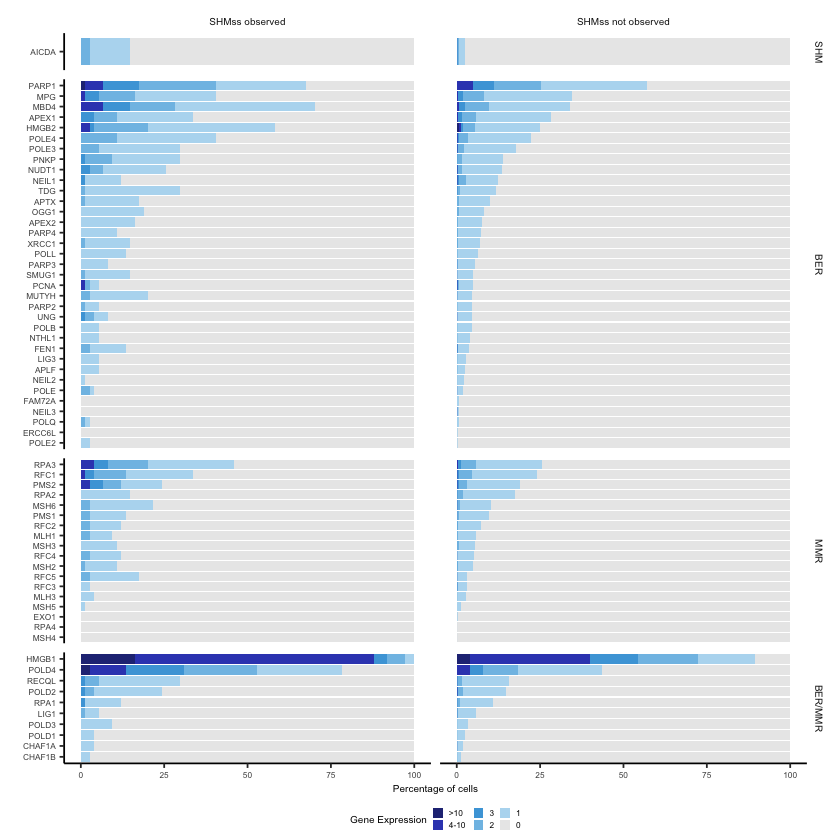

In [30]:
expre_summary <- ggplot(shm_perc_pub, aes(x = gene, y = perc, fill = expression_cat)) +
  geom_bar(stat = "identity") +
#  scale_fill_manual(values = c("#d3d3d3","#B4617A","#1c9262","#384abd","#4aa5dc","#a09ece"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +
  scale_fill_manual(values = c("#e9e9e9","#b6dbf1","#80c0e6","#4aa5dc","#384abd","#273384"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +

  labs(x = "", y = "Percentage of cells") +
  theme_classic() +
  scale_x_discrete(labels = c("neg_shm" = "SHMa not observed", "pos_shm" = "SHMa observed")) +
  theme(
    legend.position = "bottom", legend.margin = margin(t = -0.1, unit = "cm"),
    axis.text = element_text(size = 5, angle = 0),
    axis.title = element_text(size = 6),
    legend.title = element_text(size = 6), legend.text = element_text(size = 5), legend.key.size = unit(0.5, "line"),
    strip.text.x = element_text(size = 6),strip.text.y = element_text(size = 6), strip.background = element_blank()) +
  facet_grid(pathway ~ group, scales = "free", space = "free", labeller = labeller(group = group.labs)) +  #labeller = labeller(pathway = pathway.labs
  force_panelsizes(rows = c(0.1, 1,0.5,0.3)) +
  coord_flip() #+
#  scale_x_discrete(expand = c(1, 0.5,0,0)) +



fig_save(expre_summary, filename = "figs/FL/DNA_repair_expresion_norm", formats = c("pdf", "png"), width = 7, height = 12, units = "cm", dpi = 320)
expre_summary

### Integrate CLL data

In [31]:
shm_perc_pub <- read.csv("output/shm_perc_sub_nonorm.csv")  

In [32]:
shm_perc_CLL <- read.csv("output/shm_perc_sub_CLL_to_merge_no_norm.csv") 

### add combinations of columns (complete (function))

In [33]:
shm_perc_pub_int <- shm_perc_pub %>%
  bind_rows(shm_perc_CLL) %>%
    tidyr::complete(
    diagnosis, group, nesting(gene, pathway), 
    fill = list(expression_cat = "0", count = 0, perc  = 100)
  ) %>% 
                 mutate(gene = factor(gene, levels = gene_order))  %>% 
                      mutate(group = case_when(
                    (group == "SHMss_observed") & (diagnosis == "FL")  ~ "FL scSHM \n observed",
                    (group == "SHMss_not_observed") & (diagnosis == "FL")  ~ "FL scSHM \n not observed",
                    (group == "SHMss_observed") & (diagnosis == "CLL")  ~ "CLL scSHM \n observed",
                    (group == "SHMss_not_observed") & (diagnosis == "CLL")  ~ "CLL scSHM \n not observed"
                    )) %>%
                    mutate(pathway = factor(pathway, levels = c('SHM','BER','MMR','BER/MMR'))) %>% 
                    mutate(expression_cat = factor(expression_cat, levels = c('0','1','2','3','4-10','>10'))) %>%
                    mutate(group = factor(group, levels = c("FL scSHM \n observed","FL scSHM \n not observed", "CLL scSHM \n not observed","CLL scSHM \n observed")))

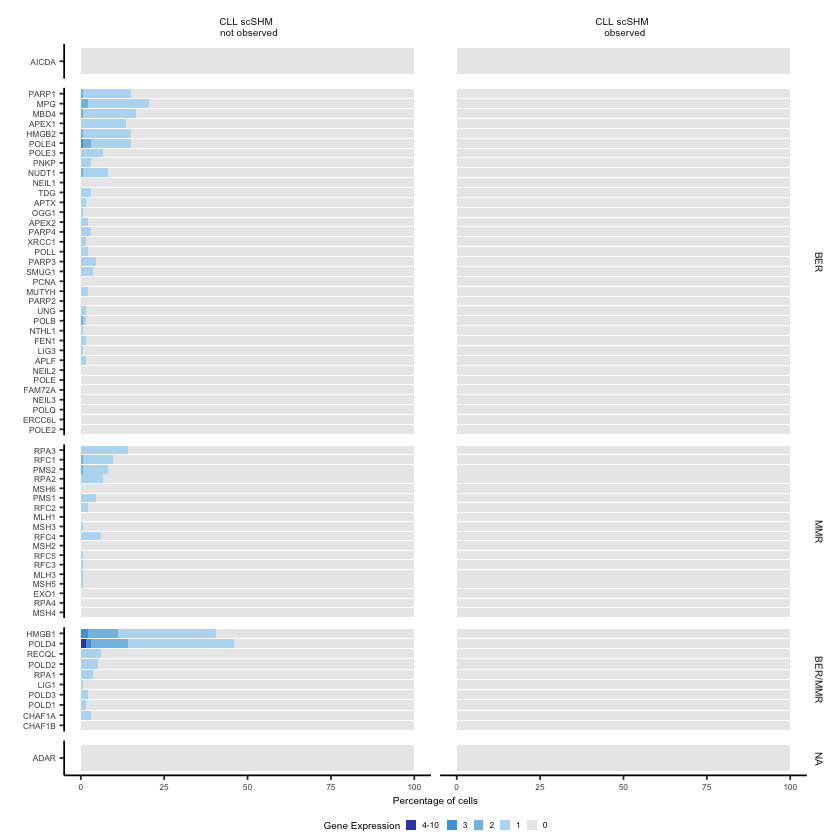

In [34]:
expre_summary <- ggplot(shm_perc_pub_int %>% filter(group != "CLL SHMss observed"), aes(x = gene, y = perc, fill = expression_cat)) +
  geom_bar(stat = "identity") +
#  scale_fill_manual(values = c("#d3d3d3","#B4617A","#1c9262","#384abd","#4aa5dc","#a09ece"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +
  scale_fill_manual(values = c("#e9e9e9","#b6dbf1","#80c0e6","#4aa5dc","#384abd","#273384"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +

  labs(x = "", y = "Percentage of cells") +
  theme_classic() +
#  scale_x_discrete(labels = c("neg_shm" = "SHMa not observed", "pos_shm" = "SHMa observed")) +
  theme(
    legend.position = "bottom", legend.margin = margin(t = -0.1, unit = "cm"),
    axis.text = element_text(size = 5, angle = 0),
    axis.title = element_text(size = 6),
    legend.title = element_text(size = 6), legend.text = element_text(size = 5), legend.key.size = unit(0.5, "line"),
    strip.text.x = element_text(size = 6),strip.text.y = element_text(size = 6), strip.background = element_blank()) +
  facet_grid(pathway ~ group, scales = "free", space = "free",labeller = labeller(pathway = pathway.labs )) +  # labeller = labeller(group = group.labs)
  force_panelsizes(rows = c(0.1, 1,0.5,0.3)) +
  coord_flip() #+
#  scale_x_discrete(expand = c(1, 0.5,0,0)) +



fig_save(expre_summary, filename = "figs/DNA_repair_expresion_no_norm", formats = c("pdf", "png"), width = 7, height = 12, units = "cm", dpi = 320)
expre_summary

## ADAR gene (RNA editing) expression analysis
**Fisher test**

In [35]:
shm_summary_adar <- shm_perc %>%
  filter(gene == "ADAR") %>%
  group_by(group, expression) %>%
  summarise(counts = sum(count)) %>%
  spread(expression, counts) %>%
  column_to_rownames(var = "group")
shm_summary_adar

`summarise()` has grouped output by 'group'. You can override using the `.groups` argument.


,No,Yes
,<int>,<int>
SHMss_observed,50,24
SHMss_not_observed,3318,890


The Fisher’s exact test is used when there is at least one cell in the contingency table of the expected frequencies below 5. To retrieve the expected frequencies, use the chisq.test() function together with $expected:

In [36]:
chisq.test(shm_summary_adar)$expected

,No,Yes
SHMss_observed,58.20458,15.79542
SHMss_not_observed,3309.79542,898.20458


In [37]:
test <- fisher.test(shm_summary_adar)
test


	Fisher's Exact Test for Count Data

data:  shm_summary_adar
p-value = 0.03049
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.3349735 0.9564944
sample estimates:
odds ratio 
 0.5589089 


In [38]:
shm_perc %>%
  filter(gene == "ADAR") %>%
  group_by(group, expression) # %>% summarise(count = sum(counts)) %>% mutate(Percentage= count * 100 / sum(count))

gene,group,expression,count,perc,pathway
<chr>,<fct>,<chr>,<int>,<dbl>,<chr>
ADAR,SHMss_observed,No,50,67.56757,RNSA_editing
ADAR,SHMss_observed,Yes,24,32.43243,RNSA_editing
ADAR,SHMss_not_observed,No,3318,78.84981,RNSA_editing
ADAR,SHMss_not_observed,Yes,890,21.15019,RNSA_editing


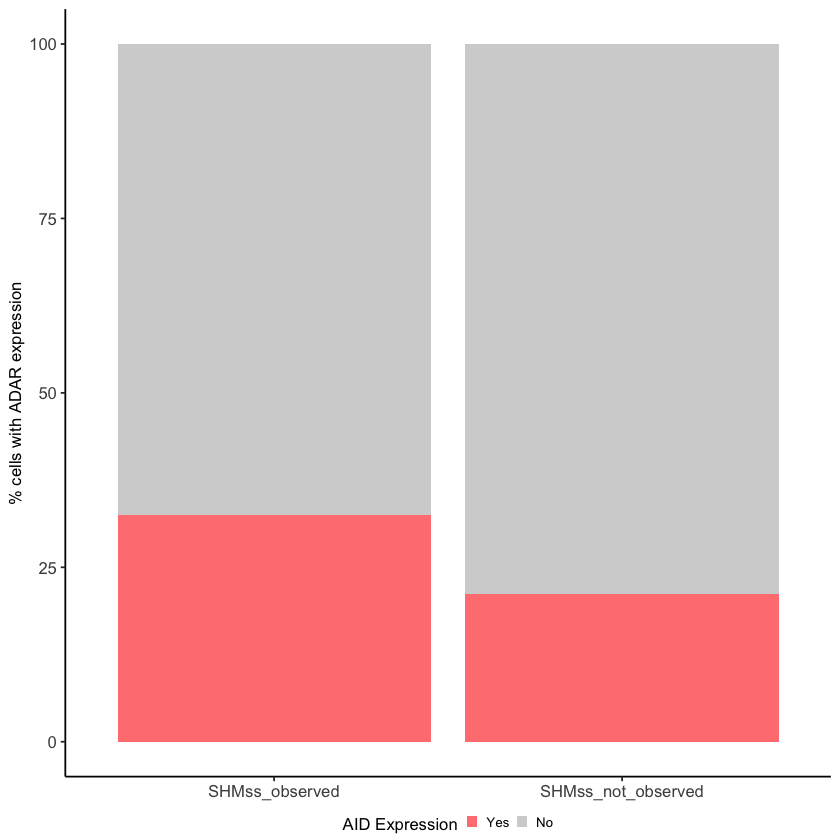

In [39]:
expre_summary <- ggplot(shm_perc %>% filter(gene == "ADAR") %>% group_by(group, expression), aes(x = group, y = perc, fill = expression)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("#d3d3d3", "#ff8181"), name = "AID Expression", guide = guide_legend(reverse = TRUE)) +
  labs(x = "", y = "% cells with ADAR expression") +
  theme_classic() +
  scale_x_discrete(labels = c("neg_shm" = "SHMa not observed", "pos_shm" = "SHMa observed")) +
  theme(
    legend.position = "bottom", legend.margin = margin(t = -0.5, unit = "cm"),
    axis.text = element_text(size = 10, angle = 0),
    axis.title = element_text(size = 10),
    legend.title = element_text(size = 10), legend.text = element_text(size = 8), legend.key.size = unit(0.5, "line")
  )


fig_save(expre_summary, filename = "figs/FL/ADAR_expression_summary", formats = c("pdf", "png"), width = 10, height = 15, units = "cm", dpi = 320)
expre_summary

## **Analysis with normalize data**

In [40]:
# filter only the GEX for the list of genes
dd <- FL_combined@assays$SCT@data %>%
  as.data.frame() %>%
  rownames_to_column(var = "gene") %>%
  filter(gene %in% genes_names$gene) %>%
  column_to_rownames(var = "gene") %>%
  t() %>%
  as.data.frame() %>%
  rownames_to_column(var = "cell")

head(dd)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,MSH6,APLF,⋯,RPA1,LIG3,PCNA,CHAF1A,XRCC1,LIG1,PNKP,POLD1,CHAF1B,MSH4
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,K1B_AAACCTGAGATCACGG-1,0.0000000,0,0.0000000,0.0000000,1.3862944,0,0,0,0.6931472,⋯,0,0,0,0,0,0.0000000,0,0,0,0
2,K1B_AAACCTGAGCCAGTTT-1,0.0000000,0,0.6931472,0.6931472,1.0986123,0,0,0,0.0000000,⋯,0,0,0,0,0,0.0000000,0,0,0,0
3,K1B_AAACCTGAGCGGCTTC-1,0.0000000,0,0.6931472,0.0000000,0.0000000,0,0,0,0.6931472,⋯,0,0,0,0,0,0.0000000,0,0,0,0
4,K1B_AAACCTGAGGCATGTG-1,0.0000000,0,0.0000000,0.0000000,0.6931472,0,0,0,0.0000000,⋯,0,0,0,0,0,0.6931472,0,0,0,0
5,K1B_AAACCTGAGTGTTTGC-1,0.6931472,0,0.0000000,0.0000000,1.3862944,0,0,0,0.0000000,⋯,0,0,0,0,0,0.0000000,0,0,0,0
6,K1B_AAACCTGCAACTGCTA-1,0.0000000,0,0.0000000,0.0000000,0.6931472,0,0,0,0.0000000,⋯,0,0,0,0,0,0.0000000,0,0,0,0


In [41]:
# clean df and include experiment column
pd <- dd %>%
  mutate(experiment = str_sub(cell, 1, 3)) %>% # str_extract("/\/$/", cell
  mutate(cell = gsub("^.{4}|.{2}$", "", cell)) # %>%
#       mutate(UNG_cat=ifelse(UNG == 0, "No", "Yes"))
head(pd)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,MSH6,APLF,⋯,LIG3,PCNA,CHAF1A,XRCC1,LIG1,PNKP,POLD1,CHAF1B,MSH4,experiment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,AAACCTGAGATCACGG,0.0000000,0,0.0000000,0.0000000,1.3862944,0,0,0,0.6931472,⋯,0,0,0,0,0.0000000,0,0,0,0,K1B
2,AAACCTGAGCCAGTTT,0.0000000,0,0.6931472,0.6931472,1.0986123,0,0,0,0.0000000,⋯,0,0,0,0,0.0000000,0,0,0,0,K1B
3,AAACCTGAGCGGCTTC,0.0000000,0,0.6931472,0.0000000,0.0000000,0,0,0,0.6931472,⋯,0,0,0,0,0.0000000,0,0,0,0,K1B
4,AAACCTGAGGCATGTG,0.0000000,0,0.0000000,0.0000000,0.6931472,0,0,0,0.0000000,⋯,0,0,0,0,0.6931472,0,0,0,0,K1B
5,AAACCTGAGTGTTTGC,0.6931472,0,0.0000000,0.0000000,1.3862944,0,0,0,0.0000000,⋯,0,0,0,0,0.0000000,0,0,0,0,K1B
6,AAACCTGCAACTGCTA,0.0000000,0,0.0000000,0.0000000,0.6931472,0,0,0,0.0000000,⋯,0,0,0,0,0.0000000,0,0,0,0,K1B


In [42]:
# merge SHMss and expression data
cell_list <- df_summary %>%
  mutate(
    experiment = str_sub(subject, 1, 3),
    group = "SHMss_observed"
  ) %>%
  select(experiment, cell, group) %>%
  distinct() %>%
  right_join(pd, by = c("cell", "experiment")) %>%
  mutate(group = ifelse(is.na(group), "SHMss_not_observed", "SHMss_observed"))

In [43]:
# remove incomplete cells and possible false positives
false_positives <- df %>%
  mutate(experiment = str_sub(subject, 1, 3), group = "SHMss_not_observed") %>%
  select(experiment, cell, group) %>%
  distinct()

cell_list <- cell_list %>%
  right_join(df_complete_cells) %>%
  anti_join(false_positives)

Joining, by = c("experiment", "cell")
Joining, by = c("experiment", "cell", "group")


In [44]:
# summarize data
shm_perc_sub <-  cell_list %>% 
  gather(-subject, -experiment, -cell, -group, key = "gene", value = "expression") %>%
  mutate(expression_cat = case_when(
     (expression > 0) & (expression < 1)  ~ ">0<1",
     (expression >= 1) & (expression <= 2)  ~ "1-2",
     (expression >2)  ~ ">2",
     TRUE ~ as.character(expression))) %>%
  select(-experiment, -cell,-expression) %>%
  group_by( gene, group, expression_cat) %>%
  summarise(count = n(), .groups="drop_last") %>%
  mutate(perc = count / sum(count) * 100) %>%
  left_join(genes_names, by = c("gene")) %>%
  mutate(group = factor(group, levels = c("SHMss_observed", "SHMss_not_observed"))) %>%
  arrange( gene, group)

In [45]:
write.csv(shm_perc_sub, "output/shm_perc_sub_norm.csv", row.names=FALSE)

### DNA repair genes expression analysis

In [46]:
#define gene order for plotting
gene_order <- shm_perc_sub %>% filter(group == "SHMss_not_observed", expression_cat == "0") %>% arrange(-perc) %>% pull(gene) %>% unique()
gene_order

[1] "MSH4"   "RPA4"   "EXO1"   "POLE2"  "ERCC6L" "POLQ"   "NEIL3"  "FAM72A"
 [9] "CHAF1B" "MSH5"   "CHAF1A" "POLE"   "NEIL2"  "POLD1"  "AICDA"  "APLF"  
[17] "LIG3"   "RFC3"   "MLH3"   "RFC5"   "POLD3"  "FEN1"   "NTHL1"  "POLB"  
[25] "UNG"    "MUTYH"  "PARP2"  "PCNA"   "MSH2"   "SMUG1"  "RFC4"   "PARP3" 
[33] "MSH3"   "LIG1"   "MLH1"   "POLL"   "XRCC1"  "APEX2"  "RFC2"   "PARP4" 
[41] "OGG1"   "PMS1"   "APTX"   "MSH6"   "RPA1"   "TDG"    "NEIL1"  "NUDT1" 
[49] "PNKP"   "POLD2"  "RECQL"  "RPA2"   "POLE3"  "PMS2"   "ADAR"   "POLE4" 
[57] "RFC1"   "HMGB2"  "RPA3"   "APEX1"  "MBD4"   "MPG"    "POLD4"  "PARP1" 
[65] "HMGB1"

In [47]:
# change name of pathway
pathway.labs <- c('','BER','BER/MMR','MMR')
names(pathway.labs) <- c('SHM','BER','BER/MMR','MMR')

# change name of group
group.labs <- c("SHMss observed","SHMss not observed")
names(group.labs) <- c("SHMss_observed","SHMss_not_observed")

In [48]:
shm_perc_pub <- shm_perc_sub %>% 
                 mutate(gene = factor(gene, levels = gene_order))  %>% 
                 filter(!gene %in% c("ADAR")) %>% 
                 mutate(pathway = factor(pathway, levels = c('SHM','BER','MMR','BER/MMR'))) %>% 
                 mutate(expression_cat = factor(expression_cat, levels = c('0','>0<1','1-2','>2'))) %>%
                 mutate(diagnosis="FL") 
#                 mutate(expression = case_when(
#     (gene == "AICDA") & (expression == "No") ~ "F",
#     (gene == "AICDA") & (expression == "Yes") ~ "T",
#     TRUE ~ expression))

In [49]:
write.csv(shm_perc_pub, "output/shm_perc_sub.csv",row.names = FALSE) 

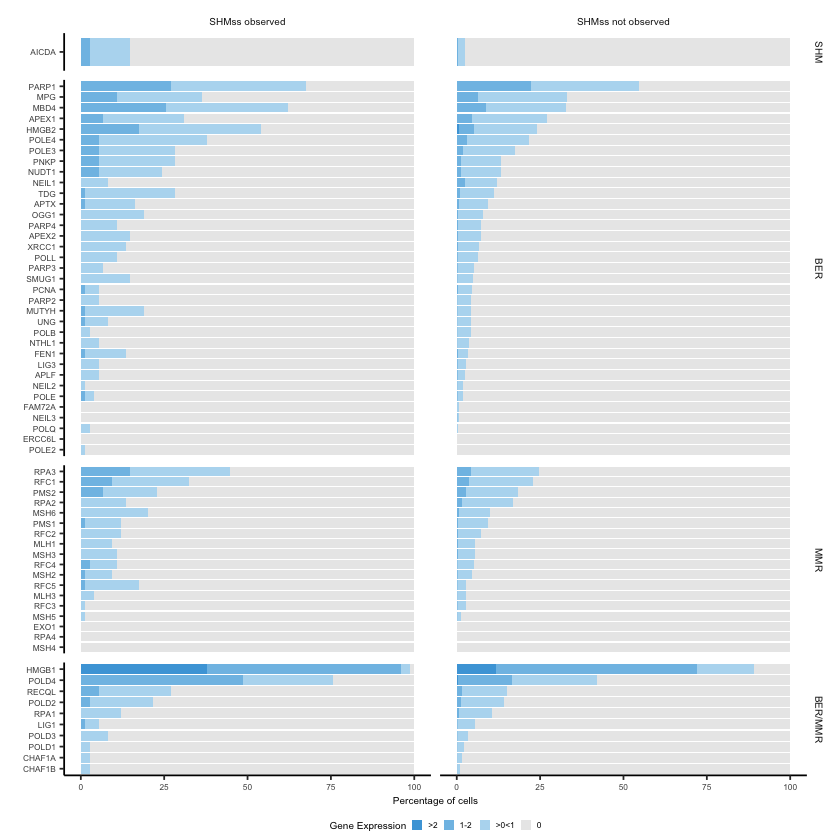

In [50]:
expre_summary <- ggplot(shm_perc_pub, aes(x = gene, y = perc, fill = expression_cat)) +
  geom_bar(stat = "identity") +
#  scale_fill_manual(values = c("#d3d3d3","#B4617A","#1c9262","#384abd","#4aa5dc","#a09ece"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +
  scale_fill_manual(values = c("#e9e9e9","#b6dbf1","#80c0e6","#4aa5dc","#384abd","#273384"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +

  labs(x = "", y = "Percentage of cells") +
  theme_classic() +
  scale_x_discrete(labels = c("neg_shm" = "SHMa not observed", "pos_shm" = "SHMa observed")) +
  theme(
    legend.position = "bottom", legend.margin = margin(t = -0.1, unit = "cm"),
    axis.text = element_text(size = 5, angle = 0),
    axis.title = element_text(size = 6),
    legend.title = element_text(size = 6), legend.text = element_text(size = 5), legend.key.size = unit(0.5, "line"),
    strip.text.x = element_text(size = 6),strip.text.y = element_text(size = 6), strip.background = element_blank()) +
  facet_grid(pathway ~ group, scales = "free", space = "free", labeller = labeller(group = group.labs)) +  #labeller = labeller(pathway = pathway.labs
  force_panelsizes(rows = c(0.1, 1,0.5,0.3)) +
  coord_flip() #+
#  scale_x_discrete(expand = c(1, 0.5,0,0)) +



fig_save(expre_summary, filename = "figs/FL/DNA_repair_expresion_norm", formats = c("pdf", "png"), width = 7, height = 12, units = "cm", dpi = 320)
expre_summary

### Integrate CLL data

In [51]:
shm_perc_pub <- read.csv("output/shm_perc_sub.csv")  

In [52]:
shm_perc_CLL <- read.csv("output/shm_perc_sub_CLL_to_merge.csv") 

**add combinations of columns (complete (function))**

In [53]:
shm_perc_pub_int <- shm_perc_pub %>%
  bind_rows(shm_perc_CLL) %>%
    tidyr::complete(
    diagnosis, group, nesting(gene, pathway), 
    fill = list(expression_cat = "0", count = 0, perc  = 100)
  ) %>% 
                 mutate(gene = factor(gene, levels = gene_order))  %>% 
                      mutate(group = case_when(
                    (group == "SHMss_observed") & (diagnosis == "FL")  ~ "FL scSHM \n observed",
                    (group == "SHMss_not_observed") & (diagnosis == "FL")  ~ "FL scSHM \n not observed",
                    (group == "SHMss_observed") & (diagnosis == "CLL")  ~ "CLL scSHM \n observed",
                    (group == "SHMss_not_observed") & (diagnosis == "CLL")  ~ "CLL scSHM \n not observed"
                    )) %>%
                    mutate(pathway = factor(pathway, levels = c('SHM','BER','MMR','BER/MMR'))) %>% 
                    mutate(expression_cat = factor(expression_cat, levels = c('0','>0<1','1-2','>2'))) %>%
                    mutate(group = factor(group, levels = c("FL scSHM \n observed","FL scSHM \n not observed", "CLL scSHM \n not observed","CLL scSHM \n observed")))

In [54]:
head(shm_perc_pub_int)

diagnosis,group,gene,pathway,expression_cat,count,perc
<chr>,<fct>,<fct>,<fct>,<fct>,<int>,<dbl>
CLL,CLL scSHM not observed,AICDA,SHM,0,0,100.000000
CLL,CLL scSHM not observed,APEX1,BER,>0<1,18,13.533835
CLL,CLL scSHM not observed,APEX1,BER,0,115,86.466165
CLL,CLL scSHM not observed,APEX2,BER,>0<1,3,2.255639
CLL,CLL scSHM not observed,APEX2,BER,0,130,97.744361
CLL,CLL scSHM not observed,APLF,BER,>0<1,2,1.503759


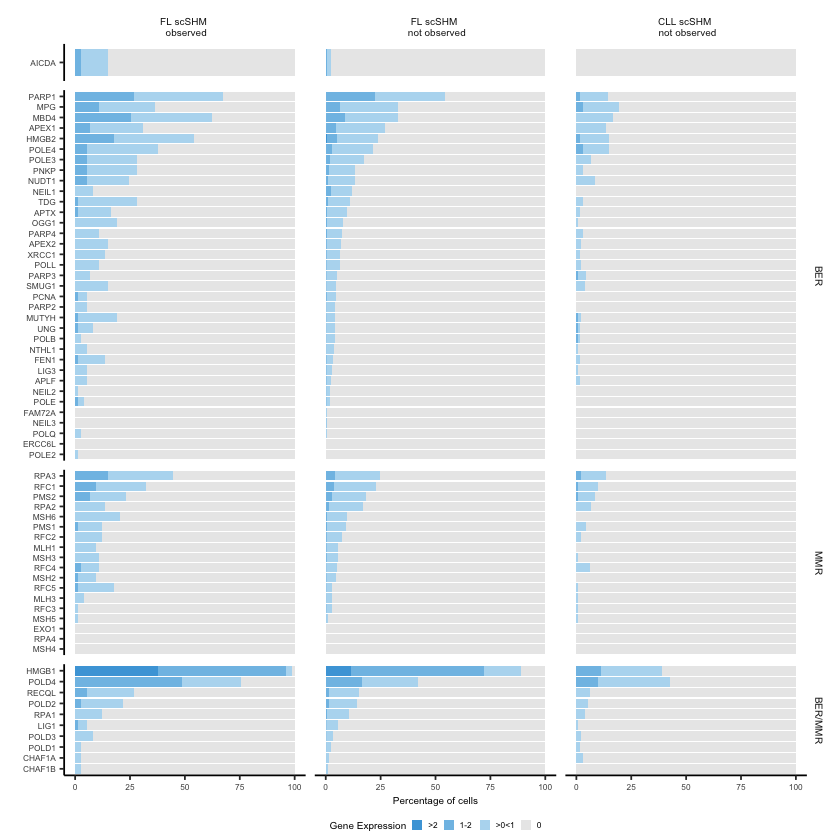

In [55]:
expre_summary <- ggplot(shm_perc_pub_int %>% filter(group != "CLL scSHM \n observed"), aes(x = gene, y = perc, fill = expression_cat)) +
  geom_bar(stat = "identity") +
#  scale_fill_manual(values = c("#d3d3d3","#B4617A","#1c9262","#384abd","#4aa5dc","#a09ece"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +
  scale_fill_manual(values = c("#e9e9e9","#b6dbf1","#80c0e6","#4aa5dc","#384abd","#273384","#384abd","#273384"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +

  labs(x = "", y = "Percentage of cells") +
  theme_classic() +
#  scale_x_discrete(labels = c("neg_shm" = "SHMa not observed", "pos_shm" = "SHMa observed")) +
  theme(
    legend.position = "bottom", legend.margin = margin(t = -0.1, unit = "cm"),
    axis.text = element_text(size = 5, angle = 0),
    axis.title = element_text(size = 6),
    legend.title = element_text(size = 6), legend.text = element_text(size = 5), legend.key.size = unit(0.5, "line"),
    strip.text.x = element_text(size = 6),strip.text.y = element_text(size = 6), strip.background = element_blank()) +
  facet_grid(pathway ~ group, scales = "free", space = "free",labeller = labeller(pathway = pathway.labs )) +  # labeller = labeller(group = group.labs)
  force_panelsizes(rows = c(0.1, 1,0.5,0.3)) +
  coord_flip() #+
#  scale_x_discrete(expand = c(1, 0.5,0,0)) +



fig_save(expre_summary, filename = "figs/DNA_repair_expresion_norm", formats = c("pdf", "png"), width = 7, height = 12, units = "cm", dpi = 320)
expre_summary

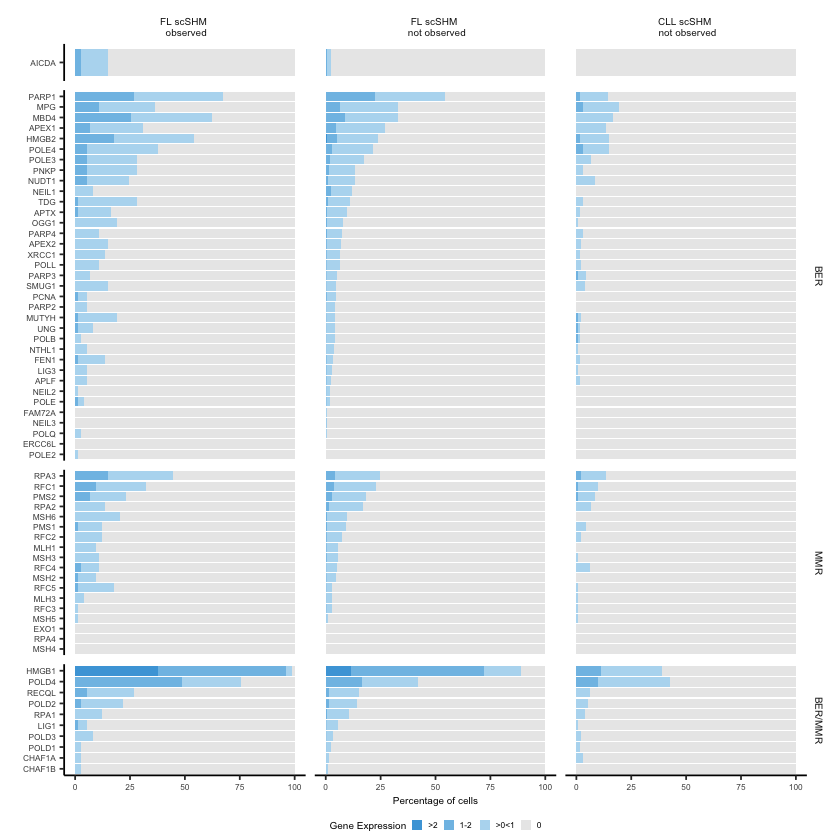

In [56]:
fig_save(expre_summary, filename = "figs/DNA_repair_expresion_norm_K123", formats = c("pdf", "png"), width = 20, height = 12, units = "cm", dpi = 320)
expre_summary